## 残差网络(ResNet)
对于深度神经网络，如果我们能将新添加的层训练成恒等映射（identity function）$f(x)=x$，新模型和原模型将同样有效。 同时，由于新模型可能得出更优的解来拟合训练数据集，因此添加层似乎更容易降低训练误差。

针对这一问题，何恺明等人提出了残差网络（ResNet） (He et al., 2016)。 它在2015年的ImageNet图像识别挑战赛夺魁，并深刻影响了后来的深度神经网络的设计。 残差网络的核心思想是：每个附加层都应该更容易地包含原始函数作为其元素之一。 于是，残差块（residual blocks）便诞生了，这个设计对如何建立深层神经网络产生了深远的影响。 凭借它，ResNet赢得了2015年ImageNet大规模视觉识别挑战赛。
ResNet沿用了VGG完整的3x3卷积层设计。 残差块里首先有2个有相同输出通道数的3x3卷积层。 每个卷积层后接一个批量规范化层和ReLU激活函数。 然后我们通过跨层数据通路，跳过这2个卷积运算，将输入直接加在最后的ReLU激活函数前。 这样的设计要求2个卷积层的输出与输入形状一样，从而使它们可以相加。 如果想改变通道数，就需要引入一个额外的1x1卷积层来将输入变换成需要的形状后再做相加运算。 残差块的实现如下：


In [17]:
import torch
from torch import nn
from torch.nn import functional as F
from d2l import torch as d2l

class Residual(nn.Module):
    def __init__(self,input_channels,num_channels,use_1x1conv=False,strides=1):
        super().__init__()
        self.conv1=nn.Conv2d(input_channels,num_channels,kernel_size=3,padding=1,stride=strides)
        self.conv2=nn.Conv2d(num_channels,num_channels,kernel_size=3,padding=1)
        if use_1x1conv:
            self.conv3=nn.Conv2d(input_channels,num_channels,kernel_size=1,stride=strides) # 为了输入和输出通道一致是input_channels
        else:
            self.conv3=None
        self.bn1=nn.BatchNorm2d(input_channels)
        self.bn2=nn.BatchNorm2d(num_channels)
    def forward(self,X):
        # Y = F.relu(self.bn1(self.conv1(X)))
        # Y = self.bn2(self.conv2(Y))
        Y = self.conv1(F.relu(self.bn1(X)))
        Y = self.conv2(F.relu(self.bn2(Y)))

        if self.conv3:
            X = self.conv3(X)
        Y += X
        return F.relu(Y)


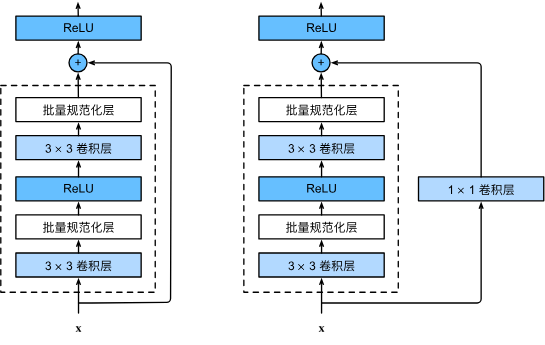<br />此代码生成两种类型的网络： 一种是当use_1x1conv=False时，应用ReLU非线性函数之前，将输入添加到输出。 另一种是当use_1x1conv=True时，添加通过1x1卷积调整通道和分辨率。

In [18]:
blk = Residual(3,3)
X = torch.rand(4,3,6,6)
Y = blk(X)
Y.shape

torch.Size([4, 3, 6, 6])

In [19]:
# 我们也可以在增加输出通道数的同时，减半输出的高和宽
blk = Residual(3,6,use_1x1conv=True,strides=2)
blk(X).shape

torch.Size([4, 6, 3, 3])

### ResNet模型
ResNet的前两层跟之前介绍的GoogLeNet中的一样： 在输出通道数为64、步幅为2的7x7卷积层后，接步幅为2的3x3的最大汇聚层。 不同之处在于ResNet每个卷积层后增加了批量规范化层。

In [20]:
b1 = nn.Sequential(nn.Conv2d(1,64,kernel_size=7,stride=2,padding=3),nn.BatchNorm2d(64),nn.ReLU(),
                   nn.MaxPool2d(kernel_size=3,stride=2,padding=1))

GoogLeNet在后面接了4个由Inception块组成的模块。 ResNet则使用4个由残差块组成的模块，每个模块使用若干个同样输出通道数的残差块。 第一个模块的通道数同输入通道数一致。 由于之前已经使用了步幅为2的最大汇聚层，所以无须减小高和宽。 之后的每个模块在第一个残差块里将上一个模块的通道数翻倍，并将高和宽减半。

下面我们来实现这个模块。注意，我们对第一个模块做了特别处理。

In [21]:
def resnet_block(input_channels,num_channels,num_residuals,first_block=False):
    blk = []
    for i in range(num_residuals):
        if i == 0 and not first_block:
            blk.append(Residual(input_channels,num_channels,use_1x1conv=True,strides=2))
        else:
            blk.append(Residual(num_channels,num_channels))
    return blk

In [22]:
# 接着在resnet中加入所有残差块，这里每个模块使用2个残差块
b2 = nn.Sequential(*resnet_block(64,64,2,first_block=True))
b3 = nn.Sequential(*resnet_block(64,128,2))
b4 = nn.Sequential(*resnet_block(128,256,2))
b5 = nn.Sequential(*resnet_block(256,512,2))
# 最后与googlenet一样在resnet中加入全局平均汇聚层，以及全连接层输出
net = nn.Sequential(b1,b2,b3,b4,b5,nn.AdaptiveAvgPool2d((1,1)),
                    nn.Flatten(),nn.Linear(512,10))

每个模块有4个卷积层（不包括恒等映射的1x1卷积层）。 加上第一个7x7卷积层和最后一个全连接层，共有18层。 因此，这种模型通常被称为ResNet-18。 通过配置不同的通道数和模块里的残差块数可以得到不同的ResNet模型，例如更深的含152层的ResNet-152。 虽然ResNet的主体架构跟GoogLeNet类似，但ResNet架构更简单，修改也更方便。这些因素都导致了ResNet迅速被广泛使用。<br/>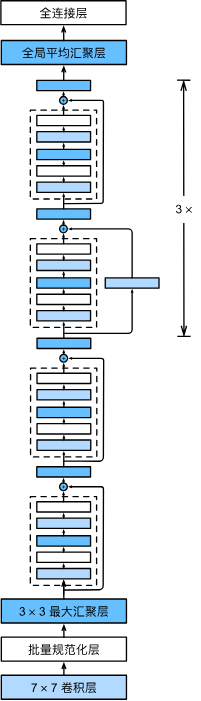<br/>在训练ResNet之前，让我们观察一下ResNet中不同模块的输入形状是如何变化的。 在之前所有架构中，分辨率降低，通道数量增加，直到全局平均汇聚层聚集所有特征。

In [23]:
X = torch.rand(size=(1, 1, 224, 224))
for layer in net:
    X = layer(X)
    print(layer.__class__.__name__,'output shape:\t', X.shape)

Sequential output shape:	 torch.Size([1, 64, 56, 56])
Sequential output shape:	 torch.Size([1, 64, 56, 56])
Sequential output shape:	 torch.Size([1, 128, 28, 28])
Sequential output shape:	 torch.Size([1, 256, 14, 14])
Sequential output shape:	 torch.Size([1, 512, 7, 7])
AdaptiveAvgPool2d output shape:	 torch.Size([1, 512, 1, 1])
Flatten output shape:	 torch.Size([1, 512])
Linear output shape:	 torch.Size([1, 10])


### 训练模型

loss 0.054, train acc 0.981, test acc 0.899
3001.4 examples/sec on cuda:0


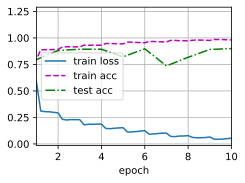

In [24]:
lr,num_epochs,batch_size=0.05,10,256
train_iter,test_iter = d2l.load_data_fashion_mnist(batch_size,resize=96)
d2l.train_ch6(net,train_iter,test_iter,num_epochs,lr,d2l.try_gpu())

### 小结
学习嵌套函数（nested function）是训练神经网络的理想情况。在深层神经网络中，学习另一层作为恒等映射（identity function）较容易（尽管这是一个极端情况）。

残差映射可以更容易地学习同一函数，例如将权重层中的参数近似为零。

利用残差块（residual blocks）可以训练出一个有效的深层神经网络：输入可以通过层间的残余连接更快地向前传播。

残差网络（ResNet）对随后的深层神经网络设计产生了深远影响。